In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# create a class for the model

def createNet(in_features:int=2, out_features:int=1, lr:float=1e-2, weights_init_type:str='Xavier', seed=None):
  '''
  Create a feedforward neural network for the wine quality dataset with specified weight initialization.
  Args:
    in_features (int): Number of input features.
    out_features (int): Number of output feat ures.
    lr (float): Learning rate for the optimizer.
    weights_init_type (str): Type of weight initialization ('Xavier' or 'Kaiming').
    seed: a random seed to use for weights initialization. None if no seed (default: none)
  Returns:
    net (nn.Module): The neural network model.
    lossfun (nn.Module): The loss function.
    optimizer (torch.optim.Optimizer): The optimizer.
  '''
  
  class ANNwine(nn.Module):
    def __init__(self):
      super().__init__()
      
      if isinstance(seed, (int, float)):
        torch.manual_seed(int(seed))

      self.input = nn.Linear(in_features,8)
      self.fc1 = nn.Linear(self.input.out_features,1)
      self.output = nn.Linear(self.fc1.out_features,out_features)
      
      # Xavier initialization
      if weights_init_type == 'Xavier':
        nn.init.xavier_uniform_(self.input.weight)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.output.weight)
      elif weights_init_type == 'Kaiming':
        nn.init.kaiming_uniform_(self.input.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.output.weight, nonlinearity='relu')
      else:
        raise ValueError("weights_init_type must be either 'Xavier' or 'Kaiming'")

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      return self.output(x)
    
    def flatten_weights(self):
      return torch.cat([p.view(-1) for p in self.parameters()]).detach().numpy()
    
    @staticmethod
    @torch.no_grad()
    def accuracy(yHat, y):
      return torch.mean(((yHat>0) == y).float()).item()
    
  net = ANNwine()
  lossfun = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(),lr=lr)
  
  return net, lossfun, optimizer

In [3]:
# Create dummy data to test the network
net, lossfun, optimizer = createNet()
X = torch.randn(64,2)
y = torch.randint(0,2,(64,1)).float()
yHat = net(X)
loss = lossfun(yHat,y)
acc = net.accuracy(yHat,y)
print(f'Loss: {loss.item():.4f}, Acc: {acc:.4f}')

Loss: 0.6939, Acc: 0.4375


In [4]:
net_dict = {'net_noseed': [None, None], 'net_rs1a': [42, None], 'net_rs2': [3, None], 'net_rs1b': [42, None]}

for k, (seed, _) in net_dict.items():
    net_dict[k][1], _, _ = createNet(seed=seed)
    print(f'{k}    \tweights sum: {np.sum(net_dict[k][1].flatten_weights())}')

net_noseed    	weights sum: -3.74141788482666
net_rs1a    	weights sum: 2.1057486534118652
net_rs2    	weights sum: -0.9728559851646423
net_rs1b    	weights sum: 2.1057486534118652


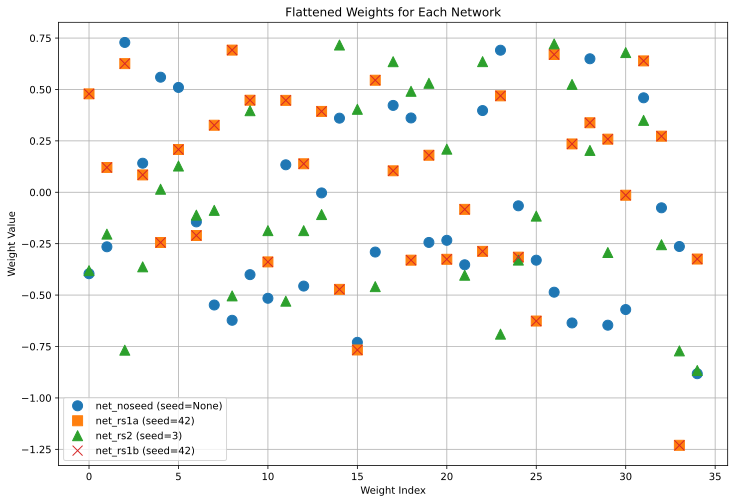

In [5]:
# Plot the flattened weights for each network
plt.figure(figsize=(12, 8))

markers = ['o', 's', '^', 'x']  
for k, (seed, net) in net_dict.items():
    weights = net.flatten_weights()
    plt.plot(weights, markers.pop(0), markersize=10, label=f'{k} (seed={seed})')

plt.xlabel('Weight Index')
plt.ylabel('Weight Value')
plt.title('Flattened Weights for Each Network')
plt.legend(loc='best')
plt.grid()
plt.show()